# Freelancer Data Analysis

## Project Overview

This project analyzes a dataset of 1,000 freelancers to understand patterns in freelancer experience, hourly rates, ratings, client satisfaction, skills, countries, and activity status.

The project includes data cleaning, exploratory data analysis, statistical analysis, and data visualization using Python.

## Objectives

- Analyze freelancer demographics and experience.
- Identify the most common freelancer skills.
- Analyze hourly rates across countries.
- Examine the relationship between experience and hourly rates.
- Compare ratings and hourly rates.
- Compare active and inactive freelancers.
- Analyze client satisfaction.
- Explore correlations between numerical variables.

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Everything is working!")

Everything is working!


In [146]:
df = pd.read_csv("../data/global_freelancers_raw.csv")

In [147]:
df.head()

,freelancer_ID,name,gender,age,country,language,primary_skill,years_of_experience,hourly_rate (USD),rating,is_active,client_satisfaction
0,FL250001,Ms. Nicole Kidd,f,52.0,Italy,Italian,Blockchain Development,11.0,100,NaN,0,NaN
1,FL250002,Vanessa Garcia,FEMALE,52.0,Australia,English,Mobile Apps,34.0,USD 100,3.3,1,84%
2,FL250003,Juan Nelson,male,53.0,Germany,German,Graphic Design,31.0,50,0.0,N,71%
3,FL250004,Amanda Spencer,F,38.0,Australia,English,Web Development,4.0,$40,1.5,N,90%
4,FL250005,Lynn Curtis DDS,female,53.0,Germany,German,Web Development,27.0,30,4.8,0,83%


In [148]:
df.shape

(1000, 12)

In [149]:
df.columns

Index(['freelancer_ID', 'name', 'gender', 'age', 'country', 'language',
       'primary_skill', 'years_of_experience', 'hourly_rate (USD)', 'rating',
       'is_active', 'client_satisfaction'],
      dtype='str')

In [150]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape:
(1000, 12)

Column Names:
['freelancer_ID', 'name', 'gender', 'age', 'country', 'language', 'primary_skill', 'years_of_experience', 'hourly_rate (USD)', 'rating', 'is_active', 'client_satisfaction']

Data Types:
freelancer_ID              str
name                       str
gender                     str
age                    float64
country                    str
language                   str
primary_skill              str
years_of_experience    float64
hourly_rate (USD)          str
rating                 float64
is_active                  str
client_satisfaction        str
dtype: object

Missing Values:
freelancer_ID            0
name                     0
gender                   0
age                     30
country                  0
language                 0
primary_skill            0
years_of_experience     51
hourly_rate (USD)       94
rating                 101
is_active               89
client_satisfaction    176
dtype: int64

Duplicate Rows:
0

First 5 Rows:

,freelancer_ID,name,gender,age,country,language,primary_skill,years_of_experience,hourly_rate (USD),rating,is_active,client_satisfaction
0,FL250001,Ms. Nicole Kidd,f,52.0,Italy,Italian,Blockchain Development,11.0,100,NaN,0,NaN
1,FL250002,Vanessa Garcia,FEMALE,52.0,Australia,English,Mobile Apps,34.0,USD 100,3.3,1,84%
2,FL250003,Juan Nelson,male,53.0,Germany,German,Graphic Design,31.0,50,0.0,N,71%
3,FL250004,Amanda Spencer,F,38.0,Australia,English,Web Development,4.0,$40,1.5,N,90%
4,FL250005,Lynn Curtis DDS,female,53.0,Germany,German,Web Development,27.0,30,4.8,0,83%


In [151]:

# DATA CLEANING
# ==========================================

# Make a copy of the original data
df_clean = df.copy()

# 1. Standardize column names
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

# 2. Clean gender values
df_clean["gender"] = (
    df_clean["gender"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "f": "female",
        "m": "male"
    })
)

# 3. Clean hourly rate
df_clean["hourly_rate_usd"] = (
    df_clean["hourly_rate_usd"]
    .astype(str)
    .str.replace("USD", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.strip()
)

df_clean["hourly_rate_usd"] = pd.to_numeric(
    df_clean["hourly_rate_usd"],
    errors="coerce"
)

# 4. Clean client satisfaction
df_clean["client_satisfaction"] = (
    df_clean["client_satisfaction"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.strip()
)

df_clean["client_satisfaction"] = pd.to_numeric(
    df_clean["client_satisfaction"],
    errors="coerce"
)

# 5. Clean is_active
df_clean["is_active"] = (
    df_clean["is_active"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "n": 0,
        "y": 1,
        "yes": 1,
        "no": 0
    })
)

df_clean["is_active"] = pd.to_numeric(
    df_clean["is_active"],
    errors="coerce"
)

# 6. Check the cleaned data
print("Cleaned Data:")
display(df_clean.head())

print("\nMissing Values After Cleaning:")
print(df_clean.isnull().sum())

print("\nData Types After Cleaning:")
print(df_clean.dtypes)

Cleaned Data:


,freelancer_id,name,gender,age,country,language,primary_skill,years_of_experience,hourly_rate_usd,rating,is_active,client_satisfaction
0,FL250001,Ms. Nicole Kidd,female,52.0,Italy,Italian,Blockchain Development,11.0,100.0,NaN,0.0,NaN
1,FL250002,Vanessa Garcia,female,52.0,Australia,English,Mobile Apps,34.0,100.0,3.3,1.0,84.0
2,FL250003,Juan Nelson,male,53.0,Germany,German,Graphic Design,31.0,50.0,0.0,0.0,71.0
3,FL250004,Amanda Spencer,female,38.0,Australia,English,Web Development,4.0,40.0,1.5,0.0,90.0
4,FL250005,Lynn Curtis DDS,female,53.0,Germany,German,Web Development,27.0,30.0,4.8,0.0,83.0



Missing Values After Cleaning:
freelancer_id            0
name                     0
gender                   0
age                     30
country                  0
language                 0
primary_skill            0
years_of_experience     51
hourly_rate_usd         94
rating                 101
is_active              263
client_satisfaction    176
dtype: int64

Data Types After Cleaning:
freelancer_id              str
name                       str
gender                     str
age                    float64
country                    str
language                   str
primary_skill              str
years_of_experience    float64
hourly_rate_usd        float64
rating                 float64
is_active              float64
client_satisfaction    float64
dtype: object


In [152]:

# HANDLE MISSING VALUES
# ==========================================

# Fill numerical columns with their median
numeric_columns = [
    "age",
    "years_of_experience",
    "hourly_rate_usd",
    "rating",
    "client_satisfaction"
]

for column in numeric_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())


# Fill is_active with the most common value (mode)
df_clean["is_active"] = df_clean["is_active"].fillna(
    df_clean["is_active"].mode()[0]
)


# VALIDATE THE CLEANED DATA


print("Missing Values After Imputation:")
print(df_clean.isnull().sum())

print("\nDuplicate Rows:")
print(df_clean.duplicated().sum())

print("\nData Types:")
print(df_clean.dtypes)

print("\nCleaned Dataset Shape:")
print(df_clean.shape)



# CHECK FOR INVALID VALUES


print("\nInvalid Ages:")
print((df_clean["age"] < 18).sum())

print("\nNegative Experience Values:")
print((df_clean["years_of_experience"] < 0).sum())

print("\nNegative Hourly Rates:")
print((df_clean["hourly_rate_usd"] < 0).sum())

print("\nRatings Outside 0-5:")
print(((df_clean["rating"] < 0) | (df_clean["rating"] > 5)).sum())

print("\nSatisfaction Outside 0-100:")
print(
    (
        (df_clean["client_satisfaction"] < 0) |
        (df_clean["client_satisfaction"] > 100)
    ).sum()
)

Missing Values After Imputation:
freelancer_id          0
name                   0
gender                 0
age                    0
country                0
language               0
primary_skill          0
years_of_experience    0
hourly_rate_usd        0
rating                 0
is_active              0
client_satisfaction    0
dtype: int64

Duplicate Rows:
0

Data Types:
freelancer_id              str
name                       str
gender                     str
age                    float64
country                    str
language                   str
primary_skill              str
years_of_experience    float64
hourly_rate_usd        float64
rating                 float64
is_active              float64
client_satisfaction    float64
dtype: object

Cleaned Dataset Shape:
(1000, 12)

Invalid Ages:
0

Negative Experience Values:
0

Negative Hourly Rates:
0

Ratings Outside 0-5:
0

Satisfaction Outside 0-100:
0


In [178]:
print("DATA CLEANING VALIDATION")
print("=" * 40)

print("Missing Values:", df_clean.isnull().sum().sum())
print("Duplicate Rows:", df_clean.duplicated().sum())

print("Invalid Ages:", (df_clean["age"] < 18).sum())
print("Negative Experience:", (df_clean["years_of_experience"] < 0).sum())
print("Negative Hourly Rates:", (df_clean["hourly_rate_usd"] < 0).sum())
print("Invalid Ratings:", ((df_clean["rating"] < 0) | (df_clean["rating"] > 5)).sum())
print(
    "Invalid Satisfaction:",
    ((df_clean["client_satisfaction"] < 0) |
     (df_clean["client_satisfaction"] > 100)).sum()
)

print("Final Dataset Shape:", df_clean.shape)

DATA CLEANING VALIDATION
Missing Values: 0
Duplicate Rows: 0
Invalid Ages: 0
Negative Experience: 0
Negative Hourly Rates: 0
Invalid Ratings: 0
Invalid Satisfaction: 0
Final Dataset Shape: (1000, 12)


In [153]:
# ==========================================
# DATA ANALYSIS
# ==========================================

df_clean.describe()

,age,years_of_experience,hourly_rate_usd,rating,is_active,client_satisfaction
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.524000,11.221000,51.290000,2.521400,0.632000,79.222000
std,11.762218,9.444329,26.259769,1.466572,0.482503,10.434059
min,20.000000,0.000000,20.000000,0.000000,0.000000,60.000000
25%,31.000000,3.000000,30.000000,1.500000,0.000000,71.000000
50%,41.000000,9.000000,40.000000,2.600000,1.000000,79.000000
75%,51.000000,17.000000,75.000000,3.700000,1.000000,87.000000
max,60.000000,41.000000,100.000000,5.000000,1.000000,100.000000


In [154]:
# ==========================================
# FREELANCERS BY COUNTRY
# ==========================================

country_counts = df_clean["country"].value_counts()

print(country_counts)

country
South Korea       68
Canada            65
Germany           52
Australia         51
Netherlands       51
United Kingdom    50
Mexico            50
United States     49
China             49
Argentina         47
Russia            47
Indonesia         46
Turkey            45
India             45
Spain             45
France            44
South Africa      44
Italy             42
Egypt             42
Japan             37
Brazil            31
Name: count, dtype: int64


In [155]:
# ==========================================
# MOST COMMON PRIMARY SKILLS
# ==========================================

skill_counts = df_clean["primary_skill"].value_counts()

print(skill_counts)

primary_skill
DevOps                    112
UI/UX Design              109
Blockchain Development    105
Web Development           104
Mobile Apps               102
AI                        100
Data Analysis              96
Graphic Design             93
Machine Learning           93
Cybersecurity              86
Name: count, dtype: int64


In [156]:
skill_counts.head(10)

primary_skill
DevOps                    112
UI/UX Design              109
Blockchain Development    105
Web Development           104
Mobile Apps               102
AI                        100
Data Analysis              96
Graphic Design             93
Machine Learning           93
Cybersecurity              86
Name: count, dtype: int64

In [157]:

# EXPERIENCE VS HOURLY RATE
# ==========================================

experience_analysis = (
    df_clean.groupby("years_of_experience")["hourly_rate_usd"]
    .mean()
    .round(2)
)

print(experience_analysis)

years_of_experience
0.0     48.06
1.0     49.38
2.0     56.87
3.0     46.96
4.0     45.71
5.0     50.27
6.0     51.25
7.0     53.00
8.0     44.59
9.0     49.55
10.0    51.81
11.0    51.86
12.0    44.23
13.0    54.03
14.0    52.00
15.0    46.43
16.0    60.00
17.0    49.52
18.0    48.95
19.0    52.22
20.0    50.95
21.0    62.93
22.0    56.36
23.0    51.00
24.0    63.64
25.0    56.11
26.0    73.00
27.0    56.43
28.0    41.00
29.0    46.25
30.0    53.64
31.0    55.00
32.0    50.00
33.0    61.92
34.0    68.33
35.0    54.00
37.0    45.00
38.0    20.00
39.0    67.50
40.0    66.25
41.0    40.00
Name: hourly_rate_usd, dtype: float64


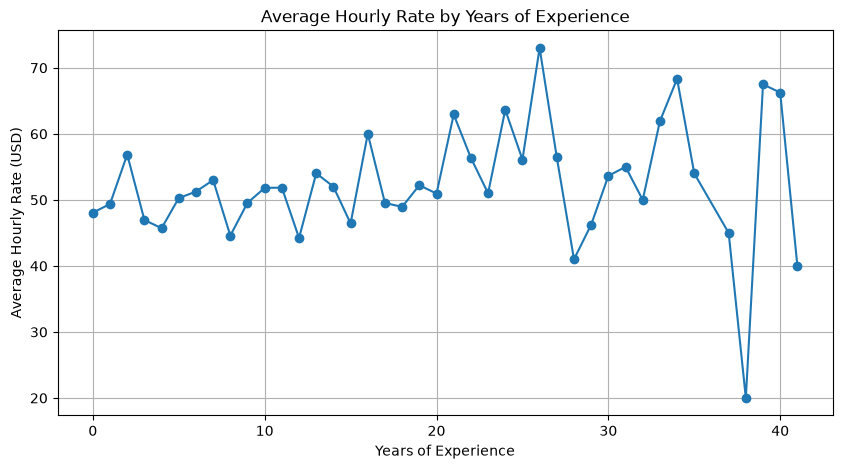

In [173]:

# EXPERIENCE VS HOURLY RATE CHART
# ==========================================

import matplotlib.pyplot as plt

experience_analysis.plot(kind="line", marker="o", figsize=(10, 5))

plt.title("Average Hourly Rate by Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Average Hourly Rate (USD)")
plt.grid(True)

plt.savefig("experience_vs_hourly_rate.png", dpi=300, bbox_inches="tight")
plt.show()

In [159]:

# HOURLY RATE BY COUNTRY
# ==========================================

country_rate = (
    df_clean.groupby("country")["hourly_rate_usd"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print(country_rate)

country
India             57.56
Argentina         57.55
Indonesia         56.52
United States     55.71
China             54.69
Australia         54.41
Italy             53.45
Turkey            53.33
South Africa      52.95
Germany           51.83
United Kingdom    51.60
Canada            49.69
Egypt             49.64
France            49.32
Brazil            48.71
South Korea       48.53
Russia            48.09
Netherlands       47.35
Mexico            46.90
Japan             45.95
Spain             43.22
Name: hourly_rate_usd, dtype: float64


In [160]:
country_rate.head(10)

country
India            57.56
Argentina        57.55
Indonesia        56.52
United States    55.71
China            54.69
Australia        54.41
Italy            53.45
Turkey           53.33
South Africa     52.95
Germany          51.83
Name: hourly_rate_usd, dtype: float64

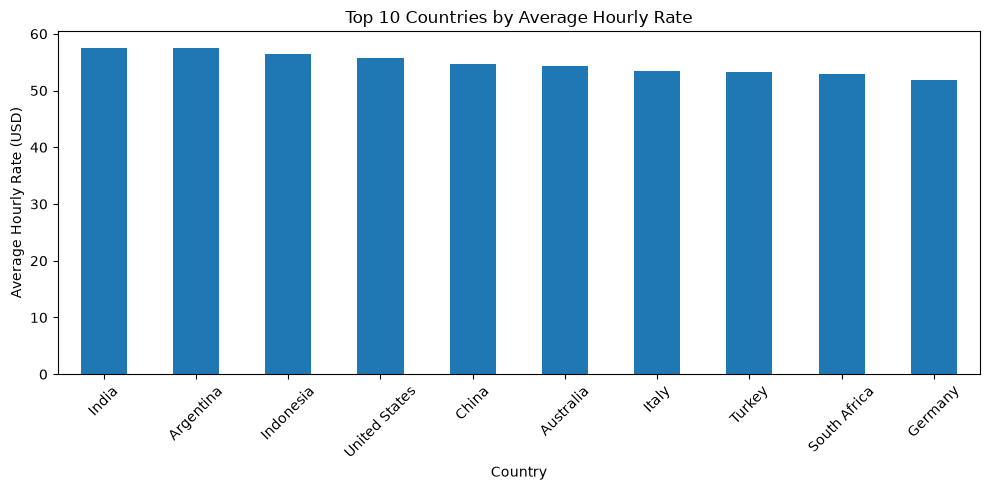

In [174]:

# TOP 10 COUNTRIES BY AVERAGE HOURLY RATE
# ==========================================

top_countries = country_rate.head(10)

top_countries.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 Countries by Average Hourly Rate")
plt.xlabel("Country")
plt.ylabel("Average Hourly Rate (USD)")
plt.xticks(rotation=45)

plt.savefig("hourly_rate_by_country.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [162]:

# RATING VS HOURLY RATE
# ==========================================

rating_analysis = (
    df_clean.groupby("rating")["hourly_rate_usd"]
    .mean()
    .round(2)
)

print(rating_analysis)

rating
0.0    50.03
1.0    43.57
1.1    52.92
1.2    45.00
1.3    43.12
1.4    55.00
1.5    57.89
1.6    48.42
1.7    51.84
1.8    51.94
1.9    48.21
2.0    50.29
2.1    60.29
2.2    51.75
2.3    52.00
2.4    47.50
2.5    53.70
2.6    49.26
2.7    50.56
2.8    52.06
2.9    60.83
3.0    66.07
3.1    50.28
3.2    51.25
3.3    48.50
3.4    55.33
3.5    56.79
3.6    48.10
3.7    64.71
3.8    49.41
3.9    39.69
4.0    53.41
4.1    46.88
4.2    43.44
4.3    63.95
4.4    62.86
4.5    56.00
4.6    55.24
4.7    50.96
4.8    47.25
4.9    41.25
5.0    48.50
Name: hourly_rate_usd, dtype: float64


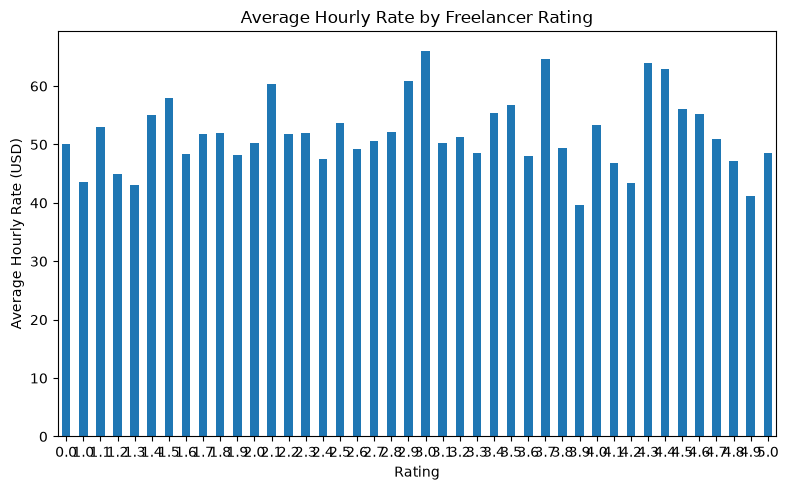

In [175]:
rating_analysis.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Hourly Rate by Freelancer Rating")
plt.xlabel("Rating")
plt.ylabel("Average Hourly Rate (USD)")
plt.xticks(rotation=0)

plt.savefig("rating_vs_hourly_rate.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [164]:

# ACTIVE VS INACTIVE FREELANCERS
# ==========================================

active_counts = df_clean["is_active"].value_counts()

print(active_counts)

is_active
1.0    632
0.0    368
Name: count, dtype: int64


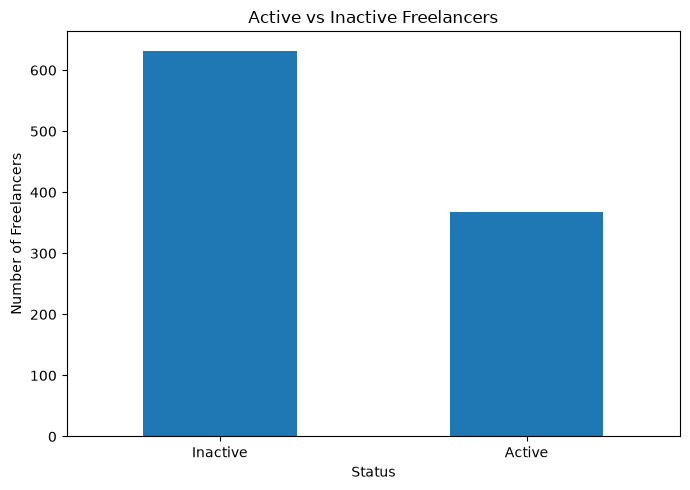

In [176]:
active_counts.index = ["Inactive", "Active"]

active_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Active vs Inactive Freelancers")
plt.xlabel("Status")
plt.ylabel("Number of Freelancers")
plt.xticks(rotation=0)

plt.savefig("active_vs_inactive.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [166]:

# CLIENT SATISFACTION BY RATING
# ==========================================

satisfaction_analysis = (
    df_clean.groupby("rating")["client_satisfaction"]
    .mean()
    .round(2)
)

print(satisfaction_analysis)

rating
0.0    80.57
1.0    76.86
1.1    76.46
1.2    76.58
1.3    77.92
1.4    77.17
1.5    77.79
1.6    78.53
1.7    72.58
1.8    80.22
1.9    80.00
2.0    79.88
2.1    79.24
2.2    78.60
2.3    78.35
2.4    76.85
2.5    77.30
2.6    80.36
2.7    80.39
2.8    79.88
2.9    80.39
3.0    78.93
3.1    82.56
3.2    78.65
3.3    77.60
3.4    77.80
3.5    81.86
3.6    79.00
3.7    80.65
3.8    80.94
3.9    79.38
4.0    80.95
4.1    78.75
4.2    80.00
4.3    80.58
4.4    80.14
4.5    77.35
4.6    81.14
4.7    75.35
4.8    79.35
4.9    78.65
5.0    82.10
Name: client_satisfaction, dtype: float64


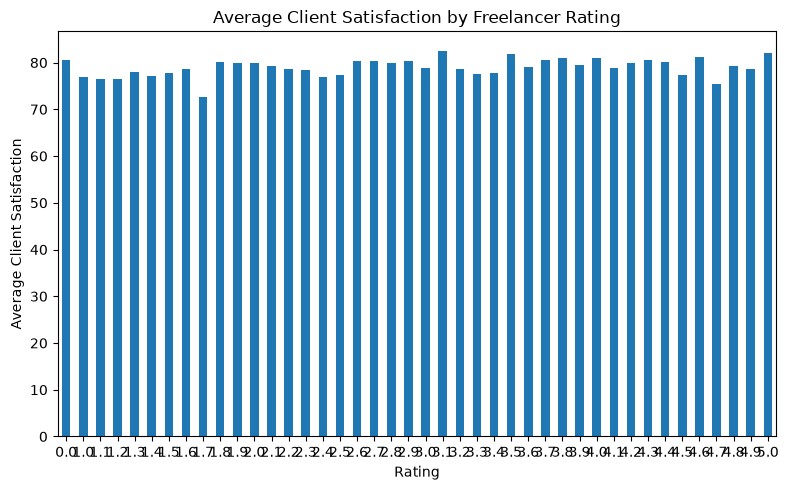

In [167]:
satisfaction_analysis.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Client Satisfaction by Freelancer Rating")
plt.xlabel("Rating")
plt.ylabel("Average Client Satisfaction")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [168]:

# MOST EXPERIENCED FREELANCERS
# ==========================================

most_experienced = df_clean.sort_values(
    "years_of_experience",
    ascending=False
)[
    [
        "name",
        "country",
        "primary_skill",
        "years_of_experience",
        "hourly_rate_usd",
        "rating",
        "client_satisfaction"
    ]
]

print(most_experienced.head(10))

                       name         country           primary_skill  \
629        Angela Blackwell          Turkey         Web Development   
964            Latoya Brown  United Kingdom            UI/UX Design   
953  Miss Kimberly Marshall  United Kingdom           Data Analysis   
760              John White           China                  DevOps   
325          Jennifer Allen           Spain           Data Analysis   
985              Bradley Wu           Spain  Blockchain Development   
559           Rodney Wilson       Argentina          Graphic Design   
601              Ryan Ewing   United States                      AI   
135           Thomas Ingram    South Africa           Cybersecurity   
69            Gina Thompson           China            UI/UX Design   

     years_of_experience  hourly_rate_usd  rating  client_satisfaction  
629                 41.0             40.0     4.9                 66.0  
964                 40.0            100.0     2.6                 79.0  

In [169]:

# ACTIVE VS INACTIVE PERFORMANCE
# ==========================================

active_analysis = (
    df_clean.groupby("is_active")[
        [
            "hourly_rate_usd",
            "rating",
            "client_satisfaction",
            "years_of_experience"
        ]
    ]
    .mean()
    .round(2)
)

active_analysis.index = ["Inactive", "Active"]

print(active_analysis)

          hourly_rate_usd  rating  client_satisfaction  years_of_experience
Inactive            50.75    2.47                79.27                10.84
Active              51.61    2.55                79.19                11.44


In [170]:

# CORRELATION ANALYSIS
# ==========================================

correlation = df_clean[
    [
        "age",
        "years_of_experience",
        "hourly_rate_usd",
        "rating",
        "client_satisfaction"
    ]
].corr()

print(correlation.round(2))

                      age  years_of_experience  hourly_rate_usd  rating  \
age                  1.00                 0.60             0.07   -0.00   
years_of_experience  0.60                 1.00             0.08    0.03   
hourly_rate_usd      0.07                 0.08             1.00    0.02   
rating              -0.00                 0.03             0.02    1.00   
client_satisfaction -0.03                -0.06            -0.05   -0.00   

                     client_satisfaction  
age                                -0.03  
years_of_experience                -0.06  
hourly_rate_usd                    -0.05  
rating                             -0.00  
client_satisfaction                 1.00  


In [ ]:
!pip install seaborn

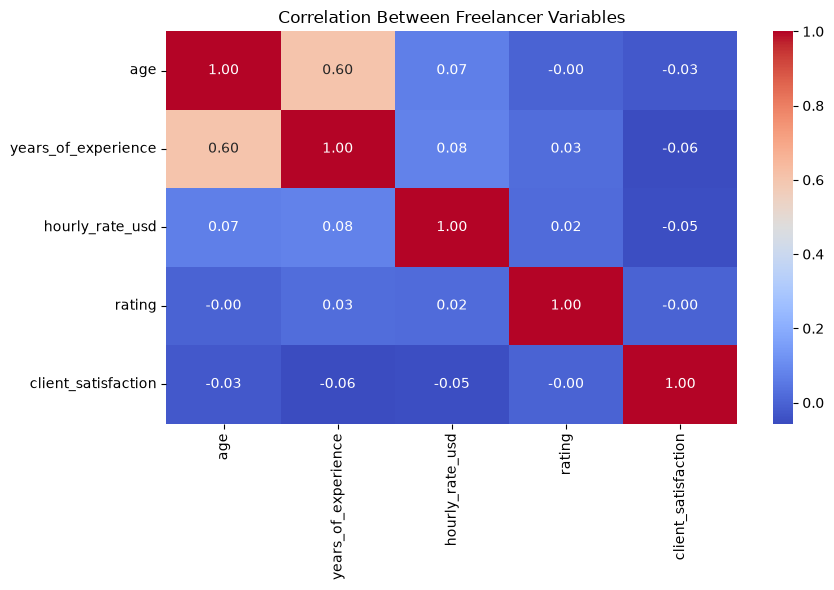

In [177]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Freelancer Variables")

plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

# Key Insights

## 1. Freelancer Overview

- The dataset contains 1,000 freelancers.
- The average freelancer age is approximately 40.5 years.
- The average years of experience is approximately 11.2 years.
- The average hourly rate is approximately $51.29.
- The average freelancer rating is approximately 2.52 out of 5.
- The average client satisfaction score is approximately 79.22 out of 100.

## 2. Freelancer Activity

- 63.2% of freelancers are active.
- Active freelancers have a slightly higher average hourly rate ($51.61) compared with inactive freelancers ($50.75).
- Active freelancers also have a slightly higher average rating (2.55 vs 2.47).

## 3. Experience and Hourly Rate

- The relationship between years of experience and hourly rate is very weak.
- The correlation between experience and hourly rate is only 0.08.
- Therefore, experience alone does not strongly determine hourly rates in this dataset.

## 4. Age and Experience

- Age and years of experience have the strongest correlation among the numerical variables.
- Their correlation is 0.60, indicating a moderate positive relationship.
- This suggests that older freelancers generally tend to have more years of experience.

## 5. Ratings and Client Satisfaction

- Rating and client satisfaction have almost no linear correlation in this dataset.
- The correlation between rating and client satisfaction is approximately 0.00.
- This suggests that a higher freelancer rating does not necessarily correspond to higher client satisfaction in this dataset.

## 6. Overall Finding

The analysis shows that freelancer hourly rates are not strongly explained by age, experience, rating, or client satisfaction. Other factors such as primary skill, country, market demand, and specialization may play a more important role.

# Conclusion

This project provided an exploratory analysis of freelancer data using Python, Pandas, Matplotlib, and Seaborn. The data was cleaned by handling missing values, checking duplicates, validating data types, and identifying invalid values.

The analysis found that experience has only a weak relationship with hourly rates, while age and experience have a moderate positive relationship. Active and inactive freelancers show very similar levels of client satisfaction, ratings, and hourly rates.

Overall, the analysis demonstrates how data cleaning, exploratory analysis, statistical relationships, and visualization can be used to identify meaningful patterns in a dataset.